In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE

np.random.seed(42)

In [226]:
n_samples = 120

df = pd.DataFrame({
    # Technical
    "diameter": np.random.uniform(10, 100, n_samples),
    "length": np.random.uniform(20, 200, n_samples),
    "mass": np.random.uniform(5, 50, n_samples),
    "speed": np.random.uniform(1000, 10000, n_samples),

    # Semantic
    "is_motor": np.random.randint(0, 2, n_samples),
    "is_turbine": np.random.randint(0, 2, n_samples),
    "has_magnet": np.random.randint(0, 2, n_samples),
    "has_cooling": np.random.randint(0, 2, n_samples),

    # Structural
    "num_components": np.random.randint(3, 15, n_samples),
    "num_connections": np.random.randint(2, 20, n_samples),
})

# ✅ FIXED LABELS (balanced!)
labels = (
    df["is_motor"] * 2 +
    df["has_magnet"] * 2 +
    (df["diameter"] > 60).astype(int) +
    (df["speed"] > 6000).astype(int)
).values

In [227]:
def build_features(df):
    tech = df[['diameter', 'length', 'mass', 'speed']].values
    semantic = df[['is_motor', 'is_turbine', 'has_magnet', 'has_cooling']].values
    structural = df[['num_components', 'num_connections']].values
    return tech, semantic, structural

tech, semantic, structural = build_features(df)

tech_scaled = StandardScaler().fit_transform(tech)

In [228]:
def cosine_sim(X):
    return cosine_similarity(X)

def semantic_sim(X):
    return 1 - pairwise_distances(X, metric='jaccard')

def structural_sim(X):
    return cosine_similarity(X)

S_cos = cosine_sim(tech_scaled)
S_sem = semantic_sim(semantic)
S_struct = structural_sim(structural)

/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [229]:
def normalize(S):
    return (S - S.min()) / (S.max() - S.min())

S_cos = normalize(S_cos)
S_sem = normalize(S_sem)
S_struct = normalize(S_struct)

In [230]:
def hybrid_sim(S_tech, S_sem, S_struct, a, b, g):
    return a * S_sem + b * S_tech + g * S_struct

In [231]:
def precision_at_k(sim_matrix, labels, k=5):
    n = sim_matrix.shape[0]
    scores = []

    for i in range(n):
        sims = sim_matrix[i]
        idx = np.argsort(sims)[::-1][1:k+1]
        relevant = (labels[idx] == labels[i]).sum()
        scores.append(relevant / k)

    return np.mean(scores)


def mean_reciprocal_rank(sim_matrix, labels):
    rr = []

    for i in range(len(labels)):
        sims = sim_matrix[i]
        idx = np.argsort(sims)[::-1][1:]

        for rank, j in enumerate(idx, start=1):
            if labels[j] == labels[i]:
                rr.append(1 / rank)
                break

    return np.mean(rr)

In [232]:
best_score = 0
best_weights = (0.4, 0.4, 0.2)

for a in np.linspace(0.3, 0.7, 9):
    for b in np.linspace(0.2, 0.5, 7):
        g = 1 - (a + b)
        if g < 0:
            continue

        S_h = hybrid_sim(S_cos, S_sem, S_struct, a, b, g)
        score = precision_at_k(S_h, labels)

        if score > best_score:
            best_score = score
            best_weights = (a, b, g)

print("Best weights:", best_weights)
print("Best Precision@5:", best_score)

Best weights: (np.float64(0.5), np.float64(0.5), np.float64(0.0))
Best Precision@5: 0.38


In [233]:
a, b, g = best_weights

S_hybrid = hybrid_sim(S_cos, S_sem, S_struct, a, b, g)

results = {
    "Cosine": precision_at_k(S_cos, labels),
    "Semantic": precision_at_k(S_sem, labels),
    "Structural": precision_at_k(S_struct, labels),
    "Hybrid": precision_at_k(S_hybrid, labels),
}

mrr = {
    "Cosine": mean_reciprocal_rank(S_cos, labels),
    "Semantic": mean_reciprocal_rank(S_sem, labels),
    "Structural": mean_reciprocal_rank(S_struct, labels),
    "Hybrid": mean_reciprocal_rank(S_hybrid, labels),
}

print("\nPrecision@5:", results)
print("MRR:", mrr)


Precision@5: {'Cosine': np.float64(0.2833333333333333), 'Semantic': np.float64(0.4066666666666668), 'Structural': np.float64(0.215), 'Hybrid': np.float64(0.38)}
MRR: {'Cosine': np.float64(0.5230926995029457), 'Semantic': np.float64(0.6218091630591631), 'Structural': np.float64(0.5316794717628052), 'Hybrid': np.float64(0.7398929615705931)}


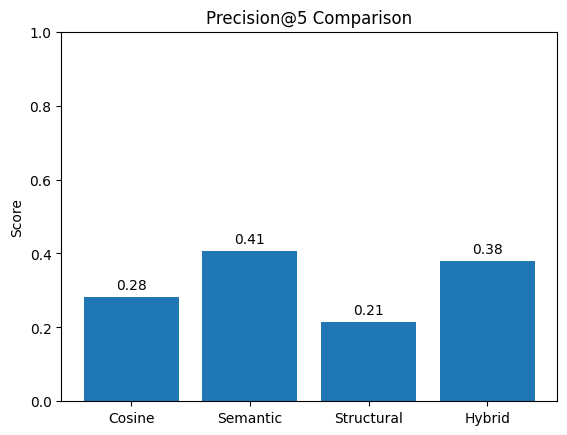

In [237]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Precision@5 Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

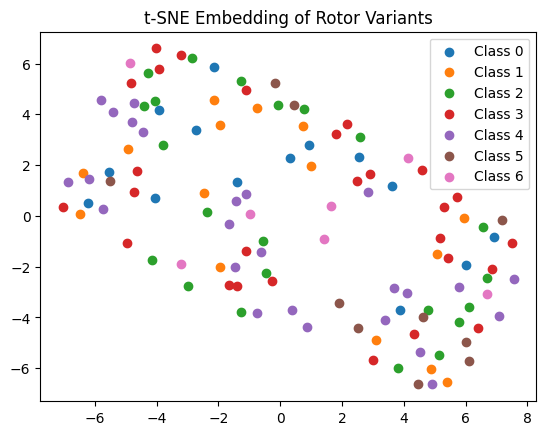

In [235]:
combined = np.hstack([tech_scaled, semantic, structural])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(combined)

plt.figure()

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"Class {label}")

plt.title("t-SNE Embedding of Rotor Variants")
plt.legend()
plt.show()

In [236]:
query_idx = 0
sims = S_hybrid[query_idx]
top_idx = np.argsort(sims)[::-1][1:6]

print("Query label:", labels[query_idx])
print("Top labels:", labels[top_idx])

Query label: 0
Top labels: [2 1 0 2 3]
